In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
adata = sc.read_h5ad('data/snRNA_data/all_celltype.h5ad')

In [3]:
celltypes = adata.obs['celltype'].unique()

In [5]:
deg = {
    '2w_up':[],
    '4w_up':[],
    '8w_up':[],
    '2w_down':[],
    '4w_down':[],
    '8w_down':[]
}
for celltype in celltypes[:7]:
    df = pd.read_csv(f'data/data/snRNA_data/deg/{celltype}.csv')
    deg['2w_up'].append(len(df[(df['COH_2w_logfoldchanges'] >= 0.25) & (df['COH_2w_pvals_adj'] < 0.01)]))
    deg['4w_up'].append(len(df[(df['COH_4w_logfoldchanges'] >= 0.25) & (df['COH_4w_pvals_adj'] < 0.01)]))
    deg['8w_up'].append(len(df[(df['COH_8w_logfoldchanges'] >= 0.25) & (df['COH_8w_pvals_adj'] < 0.01)]))
    deg['2w_down'].append(len(df[(df['COH_2w_logfoldchanges'] <= -0.25) & (df['COH_2w_pvals_adj'] < 0.01)]))
    deg['4w_down'].append(len(df[(df['COH_4w_logfoldchanges'] <= -0.25) & (df['COH_4w_pvals_adj'] < 0.01)]))
    deg['8w_down'].append(len(df[(df['COH_8w_logfoldchanges'] <= -0.25) & (df['COH_8w_pvals_adj'] < 0.01)]))

In [6]:
deg = pd.DataFrame(deg)

In [8]:
deg['celltype'] = celltypes[:7]
deg.set_index('celltype',inplace=True)
deg

,2w_up,4w_up,8w_up,2w_down,4w_down,8w_down
celltype,,,,,,
Amacrine cell,718,593,1880,59,38,19
Rod,608,1637,741,66,70,77
Muller glia,976,488,1919,107,65,102
Bipolar cell,350,1084,1635,81,25,30
Retinal ganglion cell,433,860,2783,117,46,59
Cone,507,864,1550,26,54,49
Horizontal cell,335,22,1488,15,5,54


In [9]:
cmap1 = sns.color_palette("Reds", as_cmap=True)
cmap2 = sns.color_palette("Blues", as_cmap=True) 

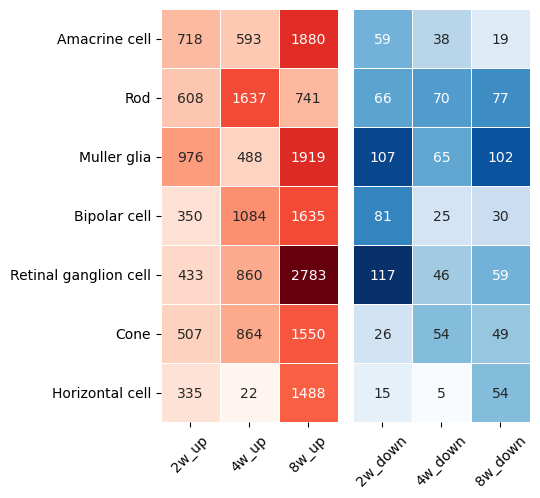

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 6))

sns.heatmap(deg.iloc[:, :3], cmap=cmap1, annot=True, fmt='d', cbar_kws={'label': 'DEG Count'}, 
            linewidths=0.5, annot_kws={'size': 10}, cbar=False, square=True, ax=axes[0])
sns.heatmap(deg.iloc[:, 3:], cmap=cmap2, annot=True, fmt='d', cbar_kws={'label': 'DEG Count'}, 
            linewidths=0.5, annot_kws={'size': 10}, cbar=False, square=True, ax=axes[1])

axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])
axes[1].tick_params(axis='y', length=0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()